In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
vgg16_quant_acc_val = {"W8A8": 84.01,
                      "W8A4": 82.58,
                      "W4A8": 83.05,
                      "W4A4": 81.19}

vgg11_quant_acc_val = {"W8A8":82.69,
                      "W8A4": 81.19,
                      "W4A8": 82.47,
                      "W4A4": 81.74}

resnet18_quant_acc_val = {"W8A8": 82.03,
                          "W8A4": 78.08,
                          "W4A8": 81.49,
                          "W4A4": 79.62}

resnet50_quant_acc_val = {"W8A8":83.90,
                          "W8A4":78.45,
                          "W4A8":81.78,
                          "W4A4":78.05}

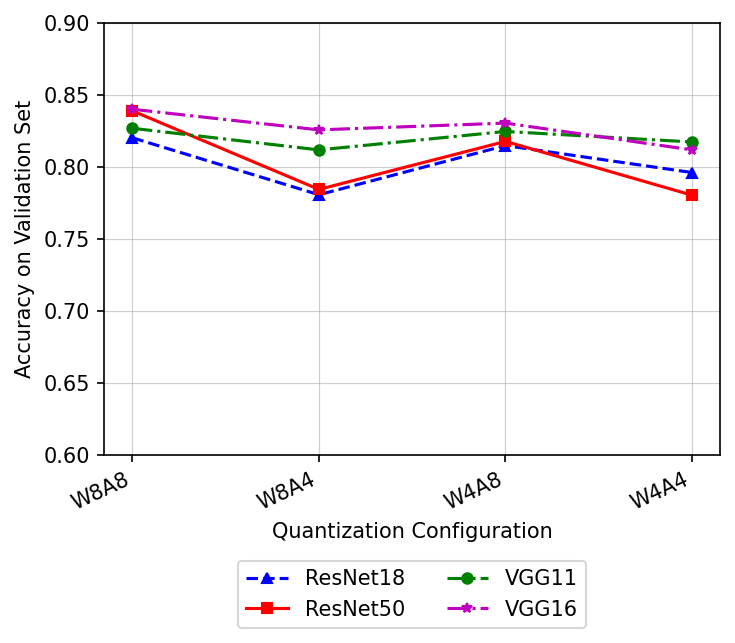

In [20]:
model_dicts = {
    "ResNet18": resnet18_quant_acc_val,
    "ResNet50": resnet50_quant_acc_val,
    "VGG11": vgg11_quant_acc_val,
    "VGG16": vgg16_quant_acc_val,
}

preferred_order = ["W8A8", "W8A4", "W4A8", "W4A4"]
all_configs = set().union(*[set(d.keys()) for d in model_dicts.values()])
quant_configs = [q for q in preferred_order if q in all_configs]
quant_configs += [q for q in sorted(all_configs) if q not in quant_configs]

def normalize_acc(v):
    return v / 100.0 if v > 1 else v

plt.figure(figsize=(5, 5), dpi=150)
styles = ["b--^", "r-s", "g-.o", "m-.*"]
for (label, qdict), style in zip(model_dicts.items(), styles):
    y = [normalize_acc(qdict.get(q, np.nan)) for q in quant_configs]
    plt.plot(quant_configs, y, style, label=label, linewidth=1.5, markersize=5)

plt.xlabel("Quantization Configuration")
plt.ylabel("Accuracy on Validation Set")
plt.xticks(rotation=25, ha="right")
plt.ylim(0.6, 0.9)
plt.grid(True, linestyle="-", linewidth=0.6, alpha=0.6)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
output_path = "quantization_accuracy_validation.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
resnet18_luts = {"W8A8": 664902,
                "W8A4": 86953,
                "W4A8": 528393, 
                "W4A4": 76276}
resnet50_luts = {"W8A8": 3786096,
                "W8A4": 218857,
                "W4A8": 3320292, 
                "W4A4": 172945}
vgg11_luts = {"W8A8": 163813,
            "W8A4": 89940,
            "W4A8": 112365,
            "W4A4": 71755}
vgg16_luts = {"W8A8": 332790,
            "W8A4": 182000,
            "W4A8": 268795,
            "W4A4": 144578}  


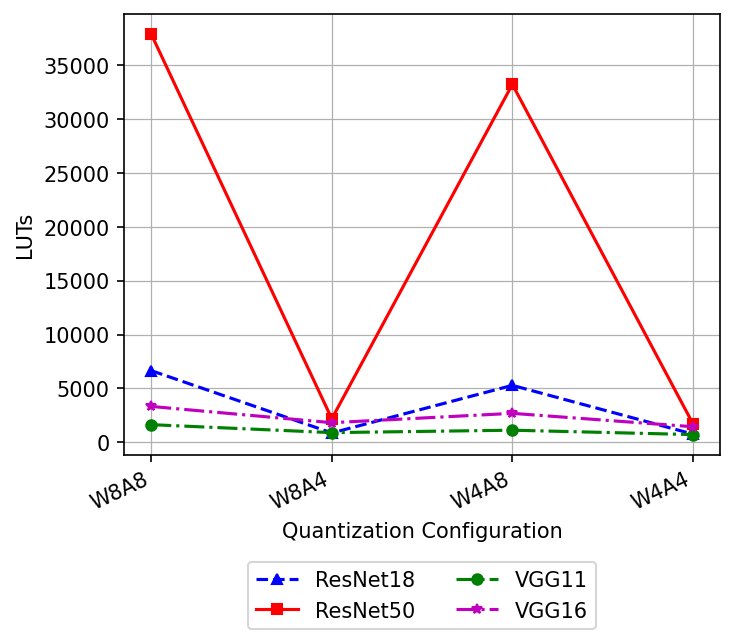

In [17]:
model_dicts = {
    "ResNet18": resnet18_luts,
    "ResNet50": resnet50_luts,
    "VGG11": vgg11_luts,
    "VGG16": vgg16_luts,
}

preferred_order = ["W8A8", "W8A4", "W4A8", "W4A4"]
all_configs = set().union(*[set(d.keys()) for d in model_dicts.values()])
quant_configs = [q for q in preferred_order if q in all_configs]
quant_configs += [q for q in sorted(all_configs) if q not in quant_configs]

def normalize_acc(v):
    return v / 100.0 if v > 1 else v

plt.figure(figsize=(5, 5), dpi=150)
styles = ["b--^", "r-s", "g-.o", "m-.*"]
for (label, qdict), style in zip(model_dicts.items(), styles):
    y = [normalize_acc(qdict.get(q, np.nan)) for q in quant_configs]
    plt.plot(quant_configs, y, style, label=label, linewidth=1.5, markersize=5)

plt.xlabel("Quantization Configuration")
plt.ylabel("LUTs")
plt.xticks(rotation=25, ha="right")
#plt.ylim(0.6, 0.9)
plt.grid(True,linewidth=0.6)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
output_path = "quantization_luts.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

In [4]:
resnet18_bram = {"W8A8": 5559,
                "W8A4": 5559,
                "W4A8": 2897, 
                "W4A4": 2897}
resnet50_bram = {"W8A8": 11745,
                "W8A4": 11745,
                "W4A8": 5867, 
                "W4A4": 5867}
vgg11_bram = {"W8A8": 7334,
            "W8A4": 7334,
            "W4A8": 3569,
            "W4A4": 3569}
vgg16_bram = {"W8A8": 9917,
            "W8A4": 9917,
            "W4A8": 4785,
            "W4A4": 4785}  

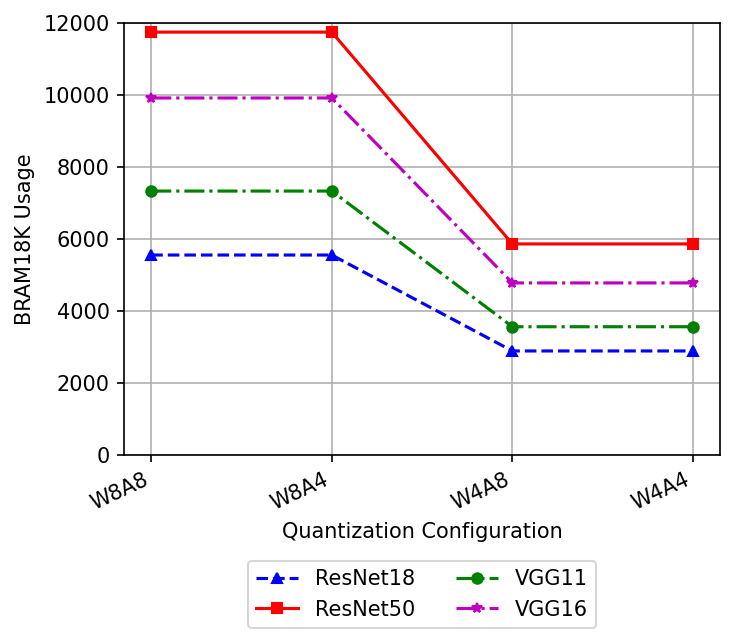

In [ ]:
model_dicts = {
    "ResNet18": resnet18_bram,
    "ResNet50": resnet50_bram,
    "VGG11": vgg11_bram,
    "VGG16": vgg16_bram,
}

preferred_order = ["W8A8", "W8A4", "W4A8", "W4A4"]
all_configs = set().union(*[set(d.keys()) for d in model_dicts.values()])
quant_configs = [q for q in preferred_order if q in all_configs]
quant_configs += [q for q in sorted(all_configs) if q not in quant_configs]

plt.figure(figsize=(5, 5), dpi=150)
styles = ["b--^", "r-s", "g-.o", "m-.*"]
for (label, qdict), style in zip(model_dicts.items(), styles):
    y = [qdict.get(q, np.nan) for q in quant_configs]
    plt.plot(quant_configs, y, style, label=label, linewidth=1.5, markersize=5)

plt.xlabel("Quantization Configuration")
plt.ylabel("BRAM18K Usage")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 12000)
plt.ticklabel_format(axis="y", style="plain")
plt.grid(True)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
output_path = "quantization_bram.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

In [18]:
resnet18_dsp = {"W8A8": 79.0,
                "W8A4": 79.0,
                "W4A8": 183.0, 
                "W4A4": 183.0}
resnet50_dsp = {"W8A8": 328.0,
                "W8A4": 328.0,
                "W4A8": 528.0, 
                "W4A4": 528.0}
vgg11_dsp = {"W8A8": 1.0,
            "W8A4": 1.0,
            "W4A8": 1.0,
            "W4A4": 1.0}
vgg16_dsp = {"W8A8": 1.0,
            "W8A4": 1.0,
            "W4A8": 1.0,
            "W4A4": 1.0}  

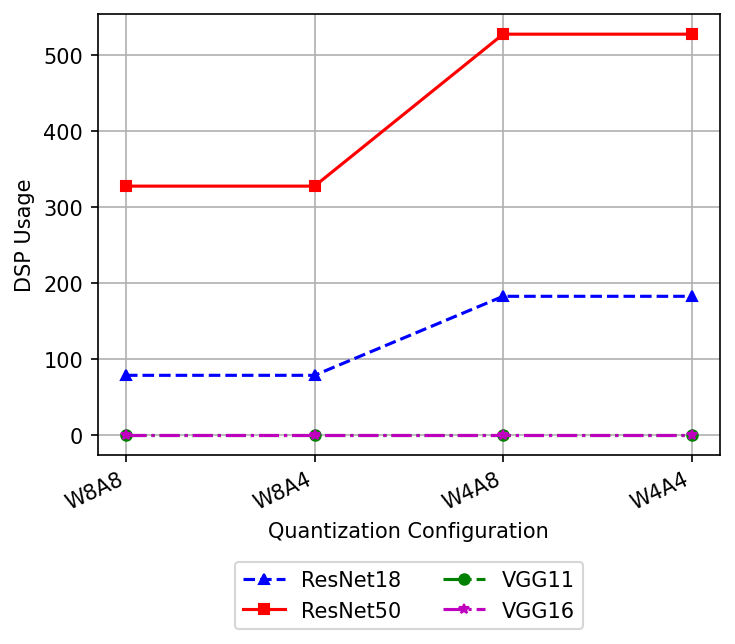

In [19]:
model_dicts = {
    "ResNet18": resnet18_dsp,
    "ResNet50": resnet50_dsp,
    "VGG11": vgg11_dsp,
    "VGG16": vgg16_dsp,
}

preferred_order = ["W8A8", "W8A4", "W4A8", "W4A4"]
all_configs = set().union(*[set(d.keys()) for d in model_dicts.values()])
quant_configs = [q for q in preferred_order if q in all_configs]
quant_configs += [q for q in sorted(all_configs) if q not in quant_configs]

plt.figure(figsize=(5, 5), dpi=150)
styles = ["b--^", "r-s", "g-.o", "m-.*"]
for (label, qdict), style in zip(model_dicts.items(), styles):
    y = [qdict.get(q, np.nan) for q in quant_configs]
    plt.plot(quant_configs, y, style, label=label, linewidth=1.5, markersize=5)

plt.xlabel("Quantization Configuration")
plt.ylabel("DSP Usage")
plt.xticks(rotation=25, ha="right")
#plt.ylim(0, 12000)
plt.ticklabel_format(axis="y", style="plain")
plt.grid(True)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
output_path = "quantization_dsp.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

# Tabs

In [ ]:
from pathlib import Path
import re
import pandas as pd

CLASS_LABELS = {
    "0": "Sem RD",
    "1": "RDNP leve",
    "2": "RDNP moderada",
    "3": "RDNP grave",
    "4": "RDP",
    "5": "Nao classificavel",
}

def normalize_model(name: str) -> str:
    key = name.strip().lower()
    if key == "resnet50":
        return "ResNet50"
    if key == "resnet18":
        return "ResNet18"
    return name.strip()

INPUT_PATH = "/home/isadora/Área de trabalho/tabela_results_avaliação.txt" 

def find_input_path() -> Path:
    patterns = ["tabela_results_avali*.txt"]
    search_dirs = [
        Path.cwd(),
        Path.home(),
        Path.home() / "Desktop",
        Path.home() / "\u00c1rea de trabalho",
    ]
    candidates = []
    for base in search_dirs:
        if not base.exists():
            continue
        for pat in patterns:
            candidates.extend(base.glob(pat))
    if not candidates and Path.home().exists():
        for pat in patterns:
            candidates.extend(Path.home().rglob(pat))
    if not candidates:
        raise FileNotFoundError(
            "Could not find tabela_results_avali*.txt. Set INPUT_PATH manually."
        )
    if len(candidates) > 1:
        print("Multiple matches found, using first:", candidates[0])
    return candidates[0]

if INPUT_PATH:
    input_path = Path(INPUT_PATH).expanduser()
else:
    input_path = find_input_path()

text = input_path.read_text(encoding="utf-8", errors="ignore")
lines = [ln.rstrip() for ln in text.splitlines()]

def new_section():
    return {"OA": None, "AA": None, "Kappa": None, "recall": {}}

rows = []
current_model = None
current_section = None
section_data = None

def finalize_section():
    if not current_model or not current_section or section_data is None:
        return
    label = current_model if current_section == "FULL" else f"{current_model}-{current_section}"
    row = {"Modelo": label}
    for cls, col_name in CLASS_LABELS.items():
        row[col_name] = section_data["recall"].get(cls, None)
    row["OA"] = section_data["OA"]
    row["AA"] = section_data["AA"]
    row["Kappa"] = section_data["Kappa"]
    rows.append(row)

for line in lines:
    m = re.match(r"^Resultados\s+(.+)$", line, re.IGNORECASE)
    if m:
        finalize_section()
        current_model = normalize_model(m.group(1))
        current_section = None
        section_data = None
        continue

    m = re.match(r"^(full[\s-]+prescision|full[\s-]+precision):", line, re.IGNORECASE)
    if m:
        finalize_section()
        current_section = "FULL"
        section_data = new_section()
        continue

    m = re.match(r"^(W\d+A\d+):", line, re.IGNORECASE)
    if m:
        finalize_section()
        current_section = m.group(1).upper()
        section_data = new_section()
        continue

    if section_data is None:
        continue

    m = re.match(r"^Validation\s+OA:\s*([0-9.]+)", line, re.IGNORECASE)
    if m:
        section_data["OA"] = float(m.group(1))
        continue

    m = re.match(r"^Validation\s+AA:\s*([0-9.]+)", line, re.IGNORECASE)
    if m:
        section_data["AA"] = float(m.group(1))
        continue

    m = re.match(r"^Validation\s+Kappa:\s*([0-9.]+)", line, re.IGNORECASE)
    if m:
        section_data["Kappa"] = float(m.group(1))
        continue

    m = re.match(r"^\s*([0-5])\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+\d+", line)
    if m:
        cls = m.group(1)
        recall = float(m.group(3))
        section_data["recall"][cls] = recall

finalize_section()

columns = ["Modelo"] + list(CLASS_LABELS.values()) + ["OA", "AA", "Kappa"]
df = pd.DataFrame(rows)
df = df.reindex(columns=columns)

numeric_cols = [c for c in df.columns if c != "Modelo"]
df[numeric_cols] = df[numeric_cols].astype(float)
df.style.format({c: "{:.4f}" for c in numeric_cols})

,Modelo,Sem RD,RDNP leve,RDNP moderada,RDNP grave,RDP,Nao classificavel,OA,AA,Kappa
0,ResNet50,0.9800,0.0000,0.8000,0.3000,0.7300,0.8200,0.8361,0.6550,0.7433
1,ResNet50-W8A8,0.9800,0.0000,0.8000,0.5100,0.6400,0.9000,0.8390,0.6285,0.7508
2,ResNet50-W8A4,0.9800,0.0000,0.6900,0.0400,0.5800,0.8200,0.8390,0.6285,0.7508
3,ResNet50-W4A8,0.9600,0.0200,0.7900,0.3800,0.6200,0.8500,0.8178,0.6656,0.7158
4,ResNet50-W4A4,0.9500,0.0000,0.7000,0.0000,0.5700,0.9200,0.7805,0.4946,0.6581
5,ResNet18,0.9700,0.0500,0.8100,0.5300,0.6900,0.8000,0.8339,0.6795,0.7443
6,ResNet18-W8A8,0.9600,0.0400,0.8200,0.3400,0.4600,0.8800,0.8203,0.6689,0.7193
7,ResNet18-W8A4,0.9800,0.0200,0.7200,0.2300,0.4900,0.7300,0.7808,0.6984,0.6511
8,ResNet18-W4A8,0.9900,0.0500,0.7200,0.3600,0.6600,0.9000,0.8149,0.6533,0.7123
9,ResNet18-W4A4,0.9400,0.0200,0.7900,0.3000,0.4600,0.8300,0.7962,0.6208,0.6825
